In [1]:
from functionss_CUDA import *
from preprocessing import *
from integration import *
import pandas as pd
import anndata as ad
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import warnings

import numpy as np
import scanpy as sc
import torch
warnings.filterwarnings('ignore')

# Data Loading

In [2]:
sc_data = pd.read_csv('./data/Mouse_Embryo/simulation_mousedata_2020_stem/E2z2/counts.csv', index_col=0)
sc_meta = pd.read_csv('./data/Mouse_Embryo/simulation_mousedata_2020_stem/E2z2/metadata.csv', index_col=0)
sc_meta_df = pd.DataFrame(sc_meta)
sc_obj = ad.AnnData(X=csr_matrix(sc_data.T.values))
sc_obj.obs['cell'] = sc_data.T.index  # cell ID
sc_obj.var['gene'] = sc_data.T.columns  # gene name
sc_obj.obsm['spatial'] = np.array(sc_obj.obs['cell'].map(lambda x: (sc_meta_df.loc[x, 'x_global'], 
                                                         sc_meta_df.loc[x, 'y_global']) if x in sc_meta_df.index else (None, None)))
sc_obj.obsm['spatial'] = np.array(sc_obj.obsm['spatial'].tolist())
sc_obj.obs['cluster'] = sc_obj.obs['cell'].map(lambda x: (sc_meta_df.loc[x, 'celltype_mapped_refined']) if x in sc_meta_df.index else (None, None))
sc_obj = sc_obj[~sc_obj.obs['cluster'].isna()].copy()
print("sc:", sc_obj)

sc: AnnData object with n_obs × n_vars = 7661 × 351
    obs: 'cell', 'cluster'
    var: 'gene'
    obsm: 'spatial'


In [3]:
st_data = pd.read_csv('./data/Mouse_Embryo/simulation_mousedata_2020_stem/E2z2/simu_st_counts.csv', index_col=0)
st_meta = pd.read_csv('./data/Mouse_Embryo/simulation_mousedata_2020_stem/E2z2/simu_st_metadata.csv', index_col=0)
st_type = pd.read_csv('./data/Mouse_Embryo/simulation_mousedata_2020_stem/E2z2/simu_st_celltype.csv', index_col=0)
st_obj = ad.AnnData(X=csr_matrix(st_data.T.values))
st_obj.obs['cell'] = st_data.T.index
st_obj.var['gene'] = st_data.T.columns
st_obj.obs.index = st_obj.obs['cell']
st_obj.obsm['spatial'] = np.array(st_obj.obs['cell'].map(lambda x: (st_meta.loc[x, 'coord_x'], 
                                                         st_meta.loc[x, 'coord_y']) if x in st_meta.index else (None, None)))
st_obj.obsm['spatial'] = np.array(st_obj.obsm['spatial'].tolist())
st_type_df = pd.DataFrame(st_type)
st_type_df['Predicted_Cell_Type'] = st_type_df.idxmax(axis=1)
st_obj.obs['cluster'] = st_obj.obs.index.map(lambda x: (st_type_df.loc[x, 'Predicted_Cell_Type']) if x in st_type_df.index else (None, None))
st_obj = st_obj[~st_obj.obs['cluster'].isna()].copy()
label_encoder = LabelEncoder()
st_obj.obs['label'] = label_encoder.fit_transform(st_obj.obs['cluster']) 
print("st:", st_obj)

st: AnnData object with n_obs × n_vars = 504 × 351
    obs: 'cell', 'cluster', 'label'
    var: 'gene'
    obsm: 'spatial'


# Preprocessing

In [4]:
sc_adata, st_adata = preprocess(sc_adata=sc_obj, st_adata=st_obj, st_type='spot', n_features=351, normalize=True,
                                    select_hvg='intersection',min_genes=50,min_cells=5)

sc_adata: AnnData object with n_obs × n_vars = 7162 × 351
    obs: 'cell', 'cluster', 'n_genes', 'source'
    var: 'gene', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', 'spatial_normalized', 'X'
st_adata: AnnData object with n_obs × n_vars = 504 × 351
    obs: 'cell', 'cluster', 'label', 'n_genes', 'source'
    var: 'gene', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p'
    obsm: 'spatial', 'spatial_normalized', 'X'
Data have been pre-processed!


# Integration

Constructing fuzzy simplicial sets ...
Initializing embedding ...
Optimizing embedding ...
	completed  0  /  300 epochs
	completed  30  /  300 epochs
	completed  60  /  300 epochs
	completed  90  /  300 epochs
	completed  120  /  300 epochs
	completed  150  /  300 epochs
	completed  180  /  300 epochs
	completed  210  /  300 epochs
	completed  240  /  300 epochs
	completed  270  /  300 epochs


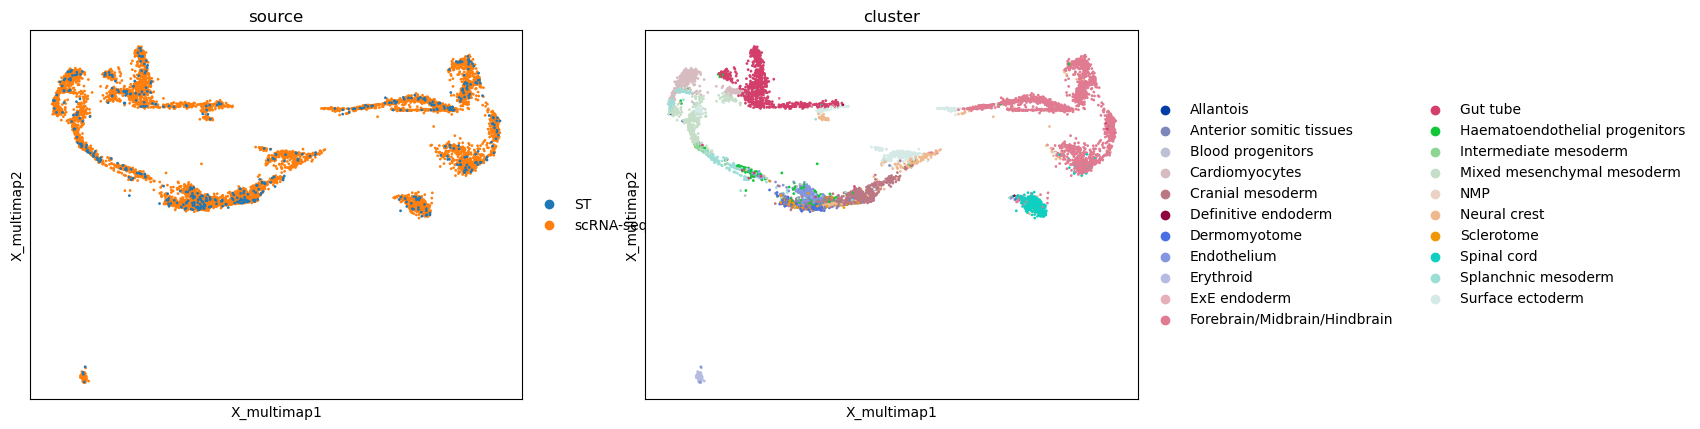

In [83]:
adata = Integration([sc_adata, st_adata], ['X', 'X'], seed=2024, n_epochs=300,n_comps=80,
                    n_neighbors=None,n_components=16,local_connectivity=1.0,spread=3.0,min_dist=0.8)

sc.pl.embedding(adata, 'X_multimap', color=['source','cluster'])

In [84]:
st_embedding = ad.AnnData(adata.uns['st_embedding'])
sc_embedding = ad.AnnData(adata.uns['sc_embedding'])
st_embedding = torch.tensor(st_embedding.X)
sc_embedding = torch.tensor(sc_embedding.X)
st_location = pd.DataFrame(st_adata.obsm['spatial'], columns=['x', 'y'])

# Spatial Prediction

In [85]:
trained_model = Fit_cord(data_train=st_embedding, out_features=2, location_data=st_location,
                                         hidden_dims=[512,256,128,64,32],
                                         num_epochs=2000, batch_size=4,
                                         initial_learning_rate=0.001,seednum=2024,dropout=0.3,
                                         weight_decay=1e-6,device="cuda:0")

100%|██████████| 126/126 [00:00<00:00, 1095.58it/s]


Epoch 1, Learning Rate: 0.001, Loss: 38141155.767822266


100%|██████████| 126/126 [00:00<00:00, 1040.39it/s]


Epoch 2, Learning Rate: 0.001, Loss: 541378.3306274414


100%|██████████| 126/126 [00:00<00:00, 939.36it/s]


...

Epoch 1998, Learning Rate: 1.953125e-06, Loss: 3219.2610454559326


100%|██████████| 126/126 [00:00<00:00, 1043.50it/s]


Epoch 1999, Learning Rate: 1.953125e-06, Loss: 3219.0369005203247


100%|██████████| 126/126 [00:00<00:00, 1036.33it/s]

Epoch 2000, Learning Rate: 9.765625e-07, Loss: 3241.096782684326


In [86]:
p_coord= Predict_cord(data_test=sc_embedding,model = trained_model,location_data=None)
sc_adata.obsm['spatial_pred']=p_coord

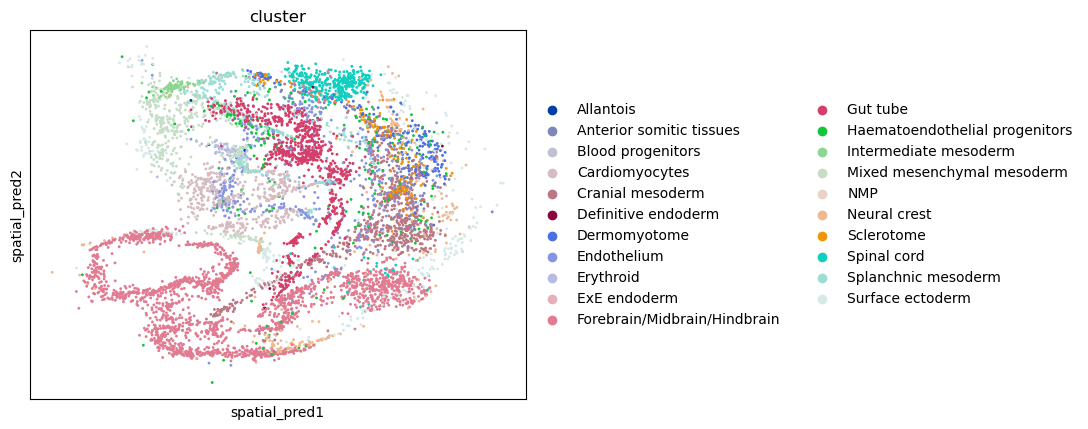

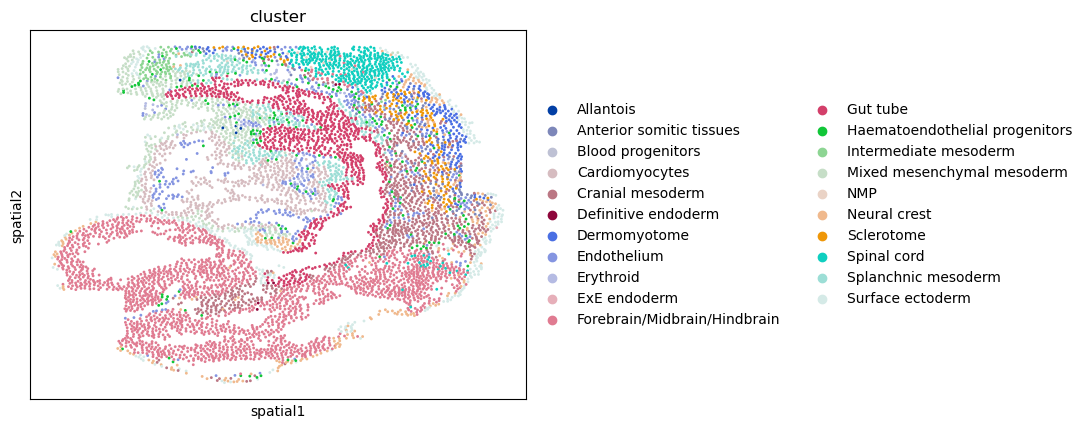

In [87]:
sc.pl.embedding(sc_adata, basis='spatial_pred', color="cluster")
sc.pl.embedding(sc_adata,basis ='spatial',color = 'cluster')

In [88]:
x = sc_adata.obsm['spatial'].astype(np.float32)
pcc = pearson_corr(torch.tensor(x),torch.tensor(p_coord))
print("PCC:",pcc)

mae = np.mean(np.abs(p_coord-x))
print(f"MAE: {mae}")

cal_dist_ = cal_dist(x, normalize=True)
cal_dist_p = cal_dist(p_coord, normalize=True)
pcc_pair = pearson_corr(torch.tensor(cal_dist_),torch.tensor(cal_dist_p))
print("pcc of pair distance",pcc_pair)

PCC: tensor(0.9860, dtype=torch.float64)
MAE: 7.4861743610619635


100%|██████████| 7162/7162 [00:28<00:00, 253.47it/s] 


pcc of pair distance tensor(0.9147, dtype=torch.float64)
